<a href="https://colab.research.google.com/github/josue131006-cpu/Summer-Camp-Week-3/blob/main/Dia_3_Pintando_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Paso 2: Invocando la Data (Nuestra primera Query desde Python)
Ahora que nuestra tabla `combates` vive dentro del motor de SQL, podemos usar el lenguaje que aprendieron hoy en la mañana con Erick para extraer exactamente la información que necesitamos.

Usaremos el comando `pd.read_sql_query()`. Este comando toma nuestra orden en lenguaje SQL, va a la base de datos, extrae las filas correspondientes y nos las devuelve ordenadas en una tabla limpia de Python.

In [9]:
import sqlite3

# Establish a connection to the SQLite database
conexion = sqlite3.connect('/content/torneo_smash.db')
print("Conexión a la base de datos establecida exitosamente.")

Conexión a la base de datos establecida exitosamente.


In [10]:
# Escribimos nuestra consulta SQL entre tres comillas triples (así podemos usar varias líneas)
# Queremos ver los nombres, los personajes, los KOs y las muertes, ordenados desde el jugador más letal

consulta_sql = """
SELECT Nombre, Personaje, KOs, Muertes
FROM combates
ORDER BY KOs DESC
"""

# Le pedimos a Pandas que ejecute la consulta en nuestra conexión de base de datos
df_filtrado = pd.read_sql_query(consulta_sql, conexion)

# ¡Mostramos el resultado en pantalla!
print("📊 Datos extraídos mediante SQL con éxito:")
df_filtrado.head(10) # head(10) nos muestra los mejores 10 registros

📊 Datos extraídos mediante SQL con éxito:


,Nombre,Personaje,KOs,Muertes
0,Jonathan,Kirby,4.0,1.0
1,maria jose,Kirby,4.0,1.0
2,Gabriel,Little mac,3.0,1.0
3,Daniel,Metaknight,3.0,2.0
4,Leonardo,shulk,2.0,2.0
5,Carlos,Game and watch,2.0,1.0
6,maria jose,Kirby,2.0,1.0
7,Violeta,Bayoneta,2.0,1.0
8,Gabriel,Little mac,2.0,2.0
9,Carlos,Game and watch,2.0,2.0


## Paso 3: Pintando con Código (Visualización Estética)
¡Llegó el momento de la recompensa visual! Las tablas numéricas son geniales para las computadoras, pero los seres humanos procesamos la información mucho mejor a través de formas y colores.

Vamos a activar el **Modo Oscuro** (el favorito de todo programador) y a diseñar nuestro primer gráfico de barras para descubrir quién se lleva la corona del jugador con más KOs en el campamento.

/tmp/ipykernel_7703/947629605.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_barras = sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129354 (\N{BOXING GLOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


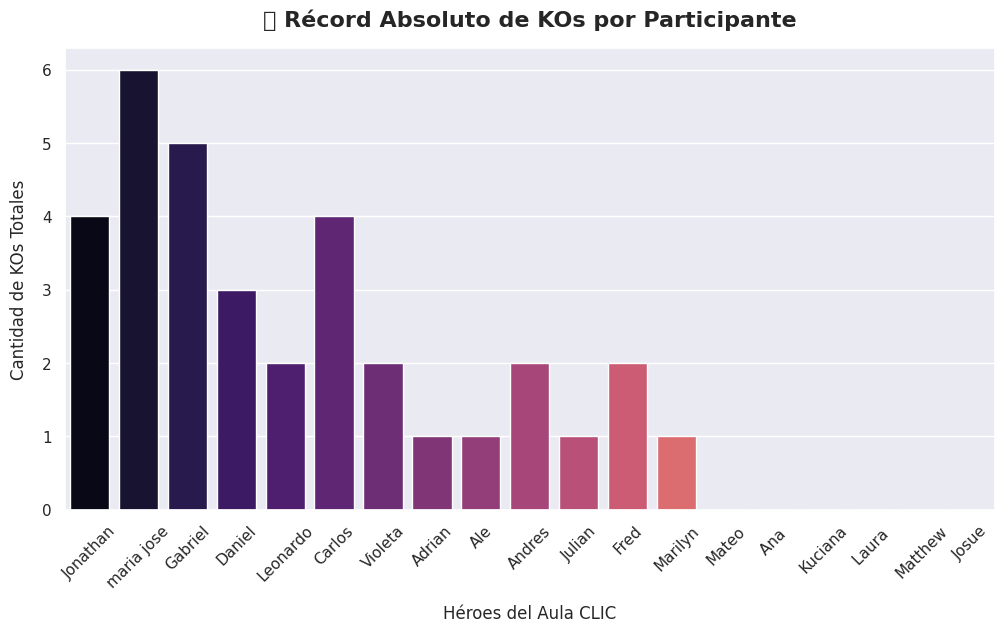

In [11]:
# 1. Activamos el estilo de rejilla oscura (Modo Gamer)

import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

# 2. Definimos el tamaño de nuestro lienzo (Ancho, Alto) en pulgadas
plt.figure(figsize=(12, 6))

# 3. Creamos el gráfico de barras.
# Añadimos estimator='sum' para sumar los KOs totales del torneo
# Añadimos errorbar=None para quitar las líneas negras de error
grafico_barras = sns.barplot(
    data=df_filtrado,
    x="Nombre",
    y="KOs",
    palette="magma",
    estimator='sum',
    errorbar=None
)

# 4. Añadimos títulos y etiquetas personalizadas para que se vea profesional
plt.title("🥊 Récord Absoluto de KOs por Participante", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Héroes del Aula CLIC", fontsize=12, labelpad=10)
plt.ylabel("Cantidad de KOs Totales", fontsize=12, labelpad=10)

# 5. Giramos los nombres de los jugadores 45 grados para que no se amontonen
plt.xticks(rotation=45)

# 6. ¡Mostramos la obra de arte!
plt.show()

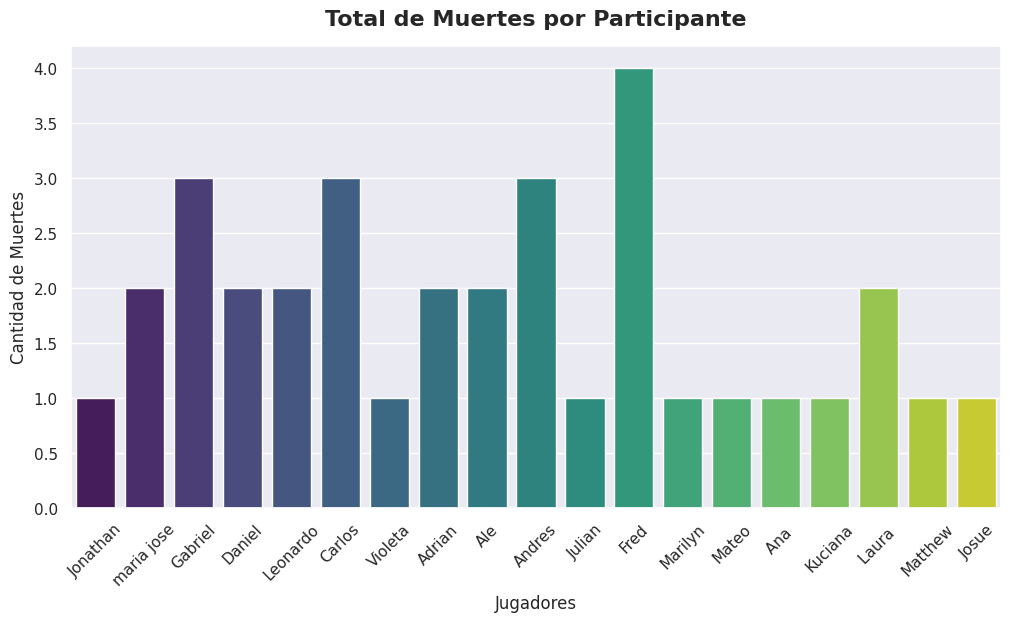

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el estilo
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# 2. Crear el gráfico usando 'Muertes'
# Agregamos hue="Nombre" y legend=False para evitar el aviso de 'FutureWarning'
grafico = sns.barplot(
    data=df_filtrado,
    x="Nombre",
    y="Muertes",
    hue="Nombre",
    legend=False,
    palette="viridis",
    estimator='sum',
    errorbar=None
)

# 3. Personalizar textos (quitamos el emoji para evitar el error de fuente)
plt.title("Total de Muertes por Participante", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Jugadores", fontsize=12)
plt.ylabel("Cantidad de Muertes", fontsize=12)
plt.xticks(rotation=45)

# 4. Mostrar
plt.show()

## Paso 4: Análisis Táctico Avanzado (Riesgo vs. Recompensa)
Un verdadero analista de datos no solo mira una variable aislada; busca **relaciones** entre ellas.

En los juegos de pelea existe el concepto de **Riesgo vs. Recompensa**: ¿Vale la pena ser súper agresivo si eso significa que también vas a morir muchas veces?

Para resolver este misterio, usaremos un **Gráfico de Dispersión (Scatter Plot)**. Cada jugador será un punto en un mapa cartesiano donde:
* Si estás **arriba a la izquierda**: Eres un jugador ultra-eficiente (Muchos KOs, pocas muertes).
* Si estás **abajo a la derecha**: Tienes que revisar tu estrategia (Pocos KOs, muchas muertes).

In [ ]:
# Definimos el tamaño del lienzo
plt.figure(figsize=(10, 7))

# Creamos el gráfico de dispersión
sns.scatterplot(
    data=df_filtrado,
    x="Muertes",        # Eje X: El riesgo asumido
    y="KOs",            # Eje Y: La recompensa obtenida
    hue="Personaje",    # ¡Color automático según el personaje elegido!
    s=200,              # Aumentamos el tamaño de los puntos para que se vean imponentes
    palette="viridis"   # Otra paleta súper estética y limpia
)

# Personalizamos los títulos
plt.title("⚖️ Mapa de Eficiencia Táctica: Riesgo vs Recompensa", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Muertes (Riesgo)", fontsize=12)
plt.ylabel("KOs Realizados (Recompensa)", fontsize=12)

# Mostramos el mapa táctico
plt.show()

---
## Paso 5: El Punto de Guardado (Save State en GitHub)
¡Felicidades, han concluido las misiones del Día 2 con éxito! Ya dominan la conexión de bases de datos y la creación de interfaces visuales con estilo profesional.

Antes de apagar las computadoras, debemos asegurar nuestro progreso guardando este nuevo cuaderno en el **MISMO repositorio** que creamos ayer. Así irán armando su portafolio paso a paso:

1. Ve al menú superior izquierdo de Colab y haz clic en **Archivo** (File).
2. Selecciona **Guardar una copia en GitHub** (Save a copy in GitHub).
3. Asegúrate de seleccionar tu repositorio de ayer (por ejemplo: `tu-usuario/key-camp-2026`).
4. En el mensaje del commit, escribe algo épico como: `"Día 2: Dominando SQL, Pandas y Gráficos Estéticos"`.
5. Haz clic en **Aceptar**.

¡Nos vemos mañana para empezar a programar aplicaciones web interactivas! 🚀